# LangChain + Neo4j

## Overview
This notebook demonstrates how to build a knowledge graph-based 
question + answering system using LangChain and Neo4j. We will:

1. Load the MovieLens dataset into a Neo4j graph database
2. Design a graph schema with Movie, Genre, and User nodes
3. Use LangChain to query the graph using natural language
4. Ask questions about movies and get answers powered by a local LLM (Ollama)

## Dataset
- **Source**: MovieLens 20M Dataset (GroupLens)
- **Contains**: 27,000 movies, 20 million ratings
- **We use**: All movies + 100,000 ratings sample

## Imports
Import the necessary libraries for this project:
- `pandas` for loading and processing the MovieLens CSV files
- `neo4j` for connecting directly to the graph database
- `langchain_community` for the GraphCypherQAChain and Neo4jGraph wrappers
- `langchain_ollama` for running a local LLM via Ollama

In [1]:
import pandas as pd
from neo4j import GraphDatabase
from langchain_ollama import ChatOllama
from langchain_neo4j import Neo4jGraph, GraphCypherQAChain

## 1. Connect to Neo4j
Connect to a local Neo4j instance running in a separate Docker container.
Note: use the container's IP address instead of `localhost` because the 
Jupyter environment runs inside Docker and cannot reach the host machine's 
`localhost` directly.

In [2]:
import langchain_neo4j_utils as lnu

# Connect to Neo4j using the utility function.
NEO4J_URI = "bolt://host.docker.internal:7687"
NEO4J_USERNAME = "neo4j"
NEO4J_PASSWORD = "password"

driver = lnu.get_driver(NEO4J_URI, NEO4J_USERNAME, NEO4J_PASSWORD)

INFO:langchain_neo4j_utils:Connecting to Neo4j at bolt://host.docker.internal:7687
INFO:langchain_neo4j_utils:Connected to Neo4j successfully.


## 2. Load MovieLens Dataset
Load the MovieLens dataset from CSV files. The dataset contains 27,000 
movies and 20 million ratings. Sample 100,000 ratings to keep ingestion 
manageable.

In [3]:
# Load MovieLens CSV files using the utility function.
movies_df, ratings_df = lnu.load_movielens(
    movies_path="movielens/movie.csv",
    ratings_path="movielens/rating.csv",
    ratings_sample=100000
)
movies_df.head()

INFO:langchain_neo4j_utils:Loading movies from movielens/movie.csv
INFO:langchain_neo4j_utils:Loaded 27278 movies.
INFO:langchain_neo4j_utils:Loading ratings from movielens/rating.csv (sample: 100000)
INFO:langchain_neo4j_utils:Loaded 100000 ratings.


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


## 3. Ingest Movies and Genres into Neo4j
Load all 27,278 movies and their genre relationships into the graph.
Each movie is split on the `|`-delimited genres string and connected
via `IN_GENRE` relationships. `MERGE` prevents duplicates on repeated runs.

In [4]:
# Ingest movies into Neo4j using the utility function.
with driver.session() as session:
    movies = movies_df.to_dict("records")
    session.execute_write(lnu.ingest_movies, movies)
    print("Movies ingested!")

Movies ingested!


## 4. Explore the Graph with Direct Cypher
Before using LangChain, verify the graph structure by running raw Cypher
queries. This confirms the schema is correct and gives intuition about
what the LLM will later need to replicate automatically.

In [5]:
# Verify graph load: count nodes and inspect sample relationships.
with driver.session() as session:
    # Count total movies and genres.
    total_movies = session.run("MATCH (m:Movie) RETURN count(m) AS total").single()["total"]
    total_genres = session.run("MATCH (g:Genre) RETURN count(g) AS total").single()["total"]
    print(f"Total movies: {total_movies}")
    print(f"Total genres: {total_genres}")

    # Sample five Action movies.
    print("\nSample Action movies:")
    result = session.run('''
        MATCH (m:Movie)-[:IN_GENRE]->(g:Genre {name: "Action"})
        RETURN m.title LIMIT 5
    ''')
    for r in result:
        print(f"  {r['m.title']}")

    # Confirm genres for a specific movie.
    print("\nGenres for Toy Story (1995):")
    result = session.run('''
        MATCH (m:Movie {title: "Toy Story (1995)"})-[:IN_GENRE]->(g:Genre)
        RETURN g.name
    ''')
    for r in result:
        print(f"  {r['g.name']}")

Total movies: 27278
Total genres: 20

Sample Action movies:
  Five, The (Gonin) (1995)
  Kill Bill: Vol. 1 (2003)
  Girl from the Naked Eye, The (2012)
  Sucker Punch (2011)
  Dragon Ball: The Curse Of The Blood Rubies (Doragon bôru: Shenron no densetsu) (1986)

Genres for Toy Story (1995):
  Fantasy
  Comedy
  Children
  Animation
  Adventure


## 5. Genre Distribution
Visualize the distribution of movies across genres to understand our dataset.
Drama and Comedy dominate the MovieLens dataset.

INFO:matplotlib.font_manager:generated new fontManager


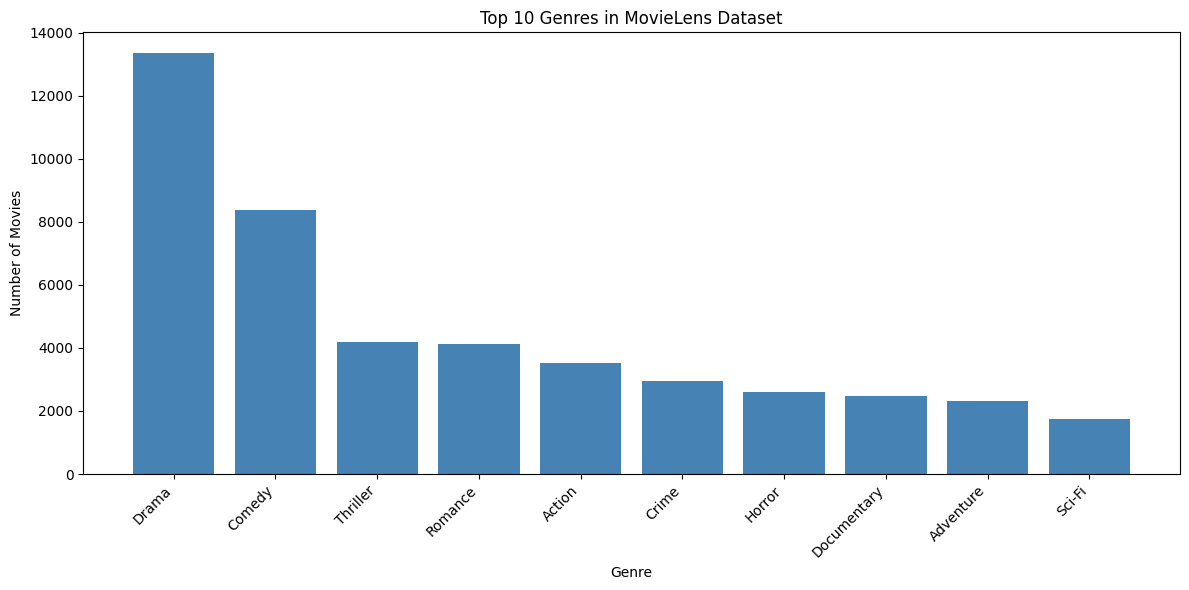

In [6]:
import matplotlib.pyplot as plt

with driver.session() as session:
    result = session.run("""
        MATCH (m:Movie)-[:IN_GENRE]->(g:Genre)
        RETURN g.name AS genre, count(m) AS total
        ORDER BY total DESC
        LIMIT 10
    """)
    data = [(r["genre"], r["total"]) for r in result]

genres = [d[0] for d in data]
counts = [d[1] for d in data]

plt.figure(figsize=(12, 6))
plt.bar(genres, counts, color="steelblue")
plt.title("Top 10 Genres in MovieLens Dataset")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 6. Ingest User Ratings

In [7]:
# Ingest ratings into Neo4j using the utility function.
with driver.session() as session:
    total = session.run("MATCH ()-[:RATED]->() RETURN count(*) AS total").single()["total"]
    if total == 0:
        print("Ingesting ratings...")
        ratings = ratings_df.to_dict("records")
        session.execute_write(lnu.ingest_ratings, ratings)
        print("Done!")
    else:
        print(f"Ratings already ingested: {total}")

Ingesting ratings...
Done!


## 7. Top Rated Movies
Query the graph for the highest rated movies

In [8]:
with driver.session() as session:
    result = session.run("""
        MATCH (u:User)-[r:RATED]->(m:Movie)
        WITH m, avg(r.rating) AS avg_rating, count(r) AS num_ratings
        WHERE num_ratings >= 50
        RETURN m.title AS title, avg_rating, num_ratings
        ORDER BY avg_rating DESC
        LIMIT 10
    """)
    for r in result:
        print(f"{r['title']}: {r['avg_rating']:.2f} ({r['num_ratings']} ratings)")

Maltese Falcon, The (1941): 4.44 (59 ratings)
Godfather: Part II, The (1974): 4.42 (137 ratings)
Shawshank Redemption, The (1994): 4.41 (305 ratings)
Rear Window (1954): 4.40 (79 ratings)
Godfather, The (1972): 4.40 (197 ratings)
One Flew Over the Cuckoo's Nest (1975): 4.35 (148 ratings)
Usual Suspects, The (1995): 4.34 (224 ratings)
Chinatown (1974): 4.33 (80 ratings)
Vertigo (1958): 4.30 (61 ratings)
Seven Samurai (Shichinin no samurai) (1954): 4.30 (55 ratings)


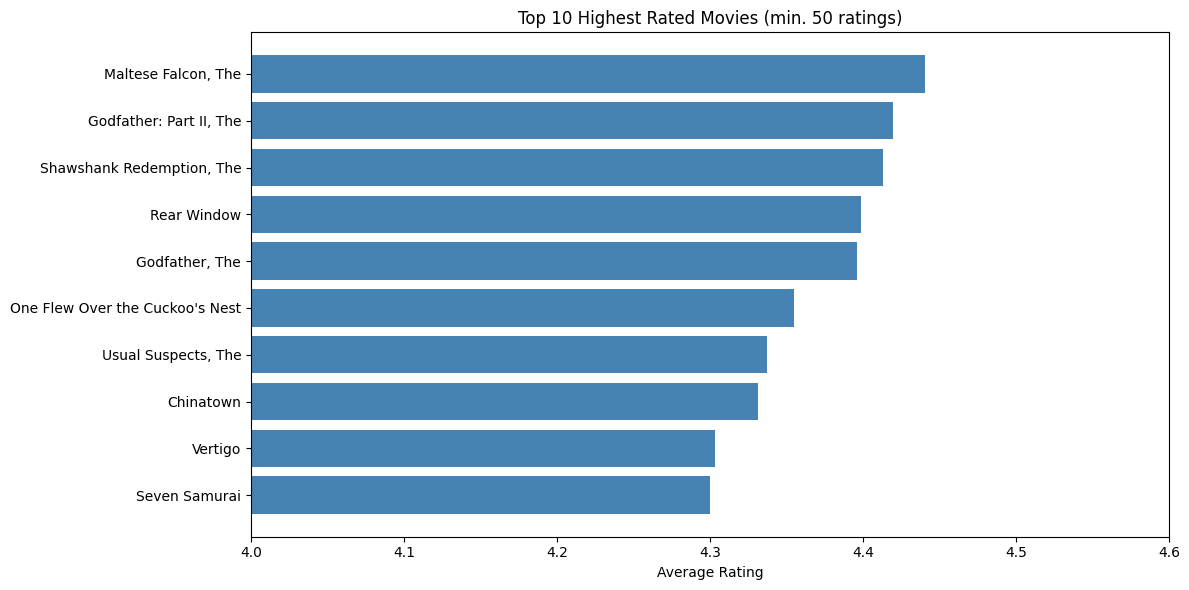

In [9]:
with driver.session() as session:
    result = session.run("""
        MATCH (u:User)-[r:RATED]->(m:Movie)
        WITH m, avg(r.rating) AS avg_rating, count(r) AS num_ratings
        WHERE num_ratings >= 50
        RETURN m.title AS title, avg_rating, num_ratings
        ORDER BY avg_rating DESC
        LIMIT 10
    """)
    data = [(r["title"], r["avg_rating"]) for r in result]

titles = [d[0].split("(")[0].strip() for d in data]  # strip year
ratings = [d[1] for d in data]

plt.figure(figsize=(12, 6))
plt.barh(titles[::-1], ratings[::-1], color="steelblue")
plt.title("Top 10 Highest Rated Movies (min. 50 ratings)")
plt.xlabel("Average Rating")
plt.xlim(4.0, 4.6)
plt.tight_layout()
plt.show()

## 8. Build the LangChain QA Chain
Assemble `GraphCypherQAChain` using `lnu.get_qa_chain()`.
1. Initialises `ChatOllama` (local `llama3.2:1b` model via Ollama)
2. Attaches a few-shot `PromptTemplate` that guides the model toward correct Cyphe
3. Wires the LLM and graph together so natural language questions are
   automatically converted to Cypher, executed, and summarised in plain English

In [10]:
# Build the Neo4jGraph wrapper and QA chain using utility functions.
graph = lnu.get_neo4j_graph(NEO4J_URI, NEO4J_USERNAME, NEO4J_PASSWORD)
chain = lnu.get_qa_chain(graph)

INFO:langchain_neo4j_utils:Initializing Neo4jGraph wrapper.
INFO:langchain_neo4j_utils:Initializing LLM: llama3.2:1b
INFO:langchain_neo4j_utils:Building GraphCypherQAChain.


## 9. Ask Natural Language Questions About Movies

In [11]:
chain.invoke("List movies in the Action genre.")



> Entering new GraphCypherQAChain chain...


INFO:httpx:HTTP Request: POST http://host.docker.internal:11434/api/chat "HTTP/1.1 200 OK"


Generated Cypher:
MATCH (m:Movie)-[:IN_GENRE]->(g:Genre {name: "Action"}) RETURN m.title LIMIT 10
Full Context:
[{'m.title': 'Five, The (Gonin) (1995)'}, {'m.title': 'Kill Bill: Vol. 1 (2003)'}, {'m.title': 'Girl from the Naked Eye, The (2012)'}, {'m.title': 'Sucker Punch (2011)'}, {'m.title': 'Dragon Ball: The Curse Of The Blood Rubies (Doragon bôru: Shenron no densetsu) (1986)'}, {'m.title': 'The Great Raid (2005)'}, {'m.title': 'Dragon Ball Z: Bio-Broly (Doragon bôru Z 11: Sûpâ senshi gekiha! Katsu no wa ore da) (1994)'}, {'m.title': 'Race with the Devil (1975)'}, {'m.title': 'Bionicle: The Legend Reborn (2009)'}, {'m.title': 'Outside the Law (2002)'}]


INFO:httpx:HTTP Request: POST http://host.docker.internal:11434/api/chat "HTTP/1.1 200 OK"



> Finished chain.


{'query': 'List movies in the Action genre.',
 'result': 'The provided information contains a list of movie titles, which can be used to create a comprehensive answer. Here\'s a possible response:\n\nThe Action genre includes films such as "Kill Bill: Vol. 1", "Dragon Ball: The Curse Of The Blood Rubies", "Sucker Punch", and others on the list provided.\n\nIf there are other movies not listed that belong to the Action genre, they can be added to the list or separately mentioned in an answer.'}

In [12]:
queries = [
    "What genres does Toy Story belong to?",
    "What are the top rated movies?",
    "How many movies are in the Drama genre?",
]
for q in queries:
    print(f"\nQ: {q}")
    result = chain.invoke(q)
    print(f"A: {result['result']}")


Q: What genres does Toy Story belong to?


> Entering new GraphCypherQAChain chain...


INFO:httpx:HTTP Request: POST http://host.docker.internal:11434/api/chat "HTTP/1.1 200 OK"


Generated Cypher:
MATCH (m:Movie {title: "Toy Story (1995)"})-[:IN_GENRE]->(g:Genre) RETURN g.name
Full Context:
[{'g.name': 'Adventure'}, {'g.name': 'Animation'}, {'g.name': 'Children'}, {'g.name': 'Comedy'}, {'g.name': 'Fantasy'}]


INFO:httpx:HTTP Request: POST http://host.docker.internal:11434/api/chat "HTTP/1.1 200 OK"



> Finished chain.
A: Toy Story is a part of the Adventure genre.

Q: What are the top rated movies?


> Entering new GraphCypherQAChain chain...


...


> Finished chain.
A: Based on the provided information, I don't know the answer to this question as it is not directly related to Neo4j stocks.

If you would like to provide more context or information about Neo4j stocks, I can try to assist you further.

Q: How many movies are in the Drama genre?


> Entering new GraphCypherQAChain chain...


INFO:httpx:HTTP Request: POST http://host.docker.internal:11434/api/chat "HTTP/1.1 200 OK"


Generated Cypher:
MATCH (m:Movie)-[:IN_GENRE]->(g:Genre {name: "Drama"}) RETURN count(m) AS total
Full Context:
[{'total': 13344}]


INFO:httpx:HTTP Request: POST http://host.docker.internal:11434/api/chat "HTTP/1.1 200 OK"



> Finished chain.
A: I don't have enough information to provide a specific number of movies in the Drama genre. However, I can tell you that according to the provided data, there is one movie titled "Drama" released this year.
